# SAC baseline on Four Rooms

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fourrooms import FourRoomsGridWorld, FourRoomsGoalWrapper
from networks import SAC_Critic
from agents import SAC_Actor
from utils import TrajectoryReplayBuffer, collect_episode, evaluate_policy, set_seed
from visualisations import plot_policy_rollouts, plot_q_diagnostics
from benchmarks import make_env, load_dataset_into_buffer
from benchmarks.visualise import collect_episode_frames, save_gif

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
env = make_env(
    benchmark="exorl",
    task="walker_walk",
    seed=0,
    render_mode="rgb_array",
    render_height=240,
    render_width=320,
    camera_id=0,
)

rollout = collect_episode_frames(env, max_steps=200)
print(rollout["num_steps"], rollout["total_reward"])

save_gif(rollout["frames"], "outputs/walker_walk.gif", fps=30)
env.close()


print(env.observation_space)
print(env.action_space)

obs, info = env.reset(seed=42)
print(obs.shape, obs.dtype)

a = env.action_space.sample()
next_obs, reward, terminated, truncated, info = env.step(a)
print(next_obs.shape, reward, terminated, truncated)

200 7.211864403050663
Box(-inf, inf, (24,), float32)
Box(-1.0, 1.0, (6,), float32)
(24,) float32
(24,) 0.1604043678890467 False False


In [3]:
def sac_train(
    benchmark,
    task,
    total_steps=300000,
    warmup_steps=10000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    lr=3e-4,
    alpha_lr=1e-4,
    replay_capacity=100000,
    updates_per_step=1.0,
    eval_every=5000,
    eval_episodes=8,
    reward_scale=1.0,
    max_grad_norm=10.0,
    seed=42,
):
    set_seed(seed)

    env = make_env(benchmark, task, seed=seed)
    eval_env = make_env(benchmark, task, seed=seed + 100)

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]

    actor = SAC_Actor(obs_dim, act_dim).to(DEVICE)
    q1 = SAC_Critic(obs_dim, act_dim).to(DEVICE)
    q2 = SAC_Critic(obs_dim, act_dim).to(DEVICE)
    q1_target = SAC_Critic(obs_dim, act_dim).to(DEVICE)
    q2_target = SAC_Critic(obs_dim, act_dim).to(DEVICE)

    q1_target.load_state_dict(q1.state_dict())
    q2_target.load_state_dict(q2.state_dict())

    for p in q1_target.parameters():
        p.requires_grad_(False)
    for p in q2_target.parameters():
        p.requires_grad_(False)

    actor_opt = optim.Adam(actor.parameters(), lr=lr)
    q_opt = optim.Adam(list(q1.parameters()) + list(q2.parameters()), lr=lr)

    log_alpha = torch.tensor(np.log(0.1), dtype=torch.float32, device=DEVICE, requires_grad=True)
    alpha_opt = optim.Adam([log_alpha], lr=alpha_lr)
    target_entropy = -float(act_dim)

    replay = TrajectoryReplayBuffer(
        capacity=replay_capacity,
        obs_dim=obs_dim,
        action_dim=act_dim,
        device=DEVICE,
    )

    def stochastic_policy(obs_np):
        obs_t = torch.as_tensor(obs_np, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            a, _ = actor.sample(obs_t)
        return a.squeeze(0).cpu().numpy().astype(np.float32)

    def deterministic_policy(obs_np):
        obs_t = torch.as_tensor(obs_np, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            mu, _ = actor(obs_t)
            a = torch.tanh(mu)
        return a.squeeze(0).cpu().numpy().astype(np.float32)

    total_env_steps = 0
    grad_steps = 0
    eval_returns = []
    start_time = time.perf_counter()

    q_loss = torch.tensor(0.0, device=DEVICE)
    actor_loss = torch.tensor(0.0, device=DEVICE)

    while total_env_steps < warmup_steps:
        ep, n = collect_episode(env, lambda _: env.action_space.sample())
        replay.add_episode(ep)
        total_env_steps += n

    while total_env_steps < total_steps:
        ep, n = collect_episode(env, stochastic_policy)
        replay.add_episode(ep)
        total_env_steps += n

        num_updates = max(1, int(updates_per_step * n))

        for _ in range(num_updates):
            batch = replay.sample(batch_size)

            obs = batch.obs.float()
            act = batch.actions.float()
            rew = reward_scale * batch.rewards.float()
            next_obs = batch.next_obs.float()
            terminated = batch.terminated.float()
            truncated = batch.truncated.float()

            # Bootstrap through truncation, stop only on real termination
            not_terminal = 1.0 - terminated

            with torch.no_grad():
                alpha = log_alpha.exp().clamp(max=10.0)

                next_a, next_logp = actor.sample(next_obs)
                target_q1 = q1_target(next_obs, next_a)
                target_q2 = q2_target(next_obs, next_a)
                target_q = torch.min(target_q1, target_q2) - alpha * next_logp
                y = rew + gamma * not_terminal * target_q

            q1_pred = q1(obs, act)
            q2_pred = q2(obs, act)
            q_loss = F.mse_loss(q1_pred, y) + F.mse_loss(q2_pred, y)

            q_opt.zero_grad()
            q_loss.backward()
            torch.nn.utils.clip_grad_norm_(list(q1.parameters()) + list(q2.parameters()), max_norm=max_grad_norm)
            q_opt.step()

            new_a, logp = actor.sample(obs)
            q_pi = torch.min(q1(obs, new_a), q2(obs, new_a))

            alpha = log_alpha.exp().clamp(max=10.0)
            actor_loss = (alpha.detach() * logp - q_pi).mean()

            actor_opt.zero_grad()
            actor_loss.backward()
            torch.nn.utils.clip_grad_norm_(actor.parameters(), max_norm=max_grad_norm)
            actor_opt.step()

            alpha_loss = -(log_alpha * (-logp.detach() - target_entropy)).mean()

            alpha_opt.zero_grad()
            alpha_loss.backward()
            alpha_opt.step()

            with torch.no_grad():
                log_alpha.clamp_(min=-10.0, max=2.0)

                for p, pt in zip(q1.parameters(), q1_target.parameters()):
                    pt.data.mul_(1.0 - tau).add_(tau * p.data)
                for p, pt in zip(q2.parameters(), q2_target.parameters()):
                    pt.data.mul_(1.0 - tau).add_(tau * p.data)

            grad_steps += 1

        if total_env_steps % eval_every < n:
            mean_ret, mean_len = evaluate_policy(
                eval_env,
                deterministic_policy,
                episodes=eval_episodes,
            )
            eval_returns.append((total_env_steps, mean_ret))
            print(
                f"[SAC] step={total_env_steps:7d} | grad={grad_steps:7d} "
                f"| eval_return={mean_ret:.3f} | eval_len={mean_len:.1f} "
                f"| q_loss={q_loss.item():.3f} | actor_loss={actor_loss.item():.3f} "
                f"| alpha={log_alpha.exp().item():.3f} "
                f"| time={time.perf_counter() - start_time:.1f}s"
            )

    env.close()
    eval_env.close()
    return actor, q1, eval_returns

## Visualisations

[SAC] step=  15000 | grad=   5000 | eval_return=25.207 | eval_len=1000.0 | q_loss=0.111 | actor_loss=-12.193 | alpha=0.165 | time=46.6s
[SAC] step=  20000 | grad=  10000 | eval_return=24.463 | eval_len=1000.0 | q_loss=0.317 | actor_loss=-27.707 | alpha=0.272 | time=88.2s
[SAC] step=  25000 | grad=  15000 | eval_return=18.849 | eval_len=1000.0 | q_loss=0.842 | actor_loss=-50.968 | alpha=0.448 | time=129.7s
[SAC] step=  30000 | grad=  20000 | eval_return=24.159 | eval_len=1000.0 | q_loss=42.751 | actor_loss=-87.637 | alpha=0.739 | time=170.2s
[SAC] step=  35000 | grad=  25000 | eval_return=29.639 | eval_len=1000.0 | q_loss=148.664 | actor_loss=-146.040 | alpha=1.219 | time=211.5s
[SAC] step=  40000 | grad=  30000 | eval_return=25.163 | eval_len=1000.0 | q_loss=18.397 | actor_loss=-242.399 | alpha=2.009 | time=252.7s
[SAC] step=  45000 | grad=  35000 | eval_return=21.964 | eval_len=1000.0 | q_loss=38.716 | actor_loss=-406.264 | alpha=3.313 | time=294.1s
[SAC] step=  50000 | grad=  40000 |

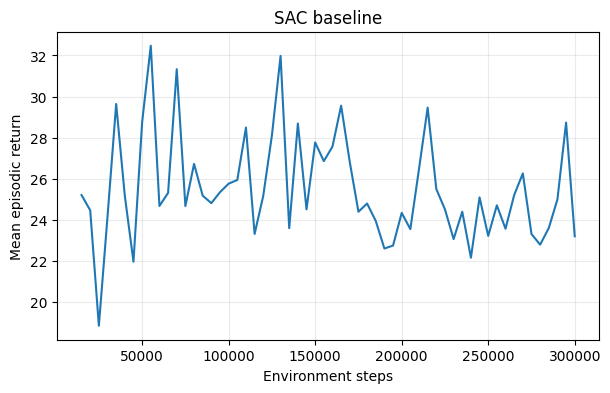

In [4]:
sac_actor, sac_q1, sac_eval = sac_train(
    benchmark="exorl",
    task="walker_walk",
    total_steps=300_000,
    seed=42,
)

if sac_eval:
    xs, ys = zip(*sac_eval)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel("Environment steps")
    plt.ylabel("Mean episodic return")
    plt.title("SAC baseline")
    plt.grid(alpha=0.25)
    plt.show()